In [124]:
import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'

In [125]:
prices         = pd.read_parquet('../data/monthly-etf-prices.parquet')
returns        = prices.pct_change().dropna(how='all')

excess_returns = returns - returns['BIL'].values.reshape(-1,1) # use BIL as risk free rate
excess_returns = excess_returns.drop(columns=['BIL'])

### Look at SPY Alone

[]

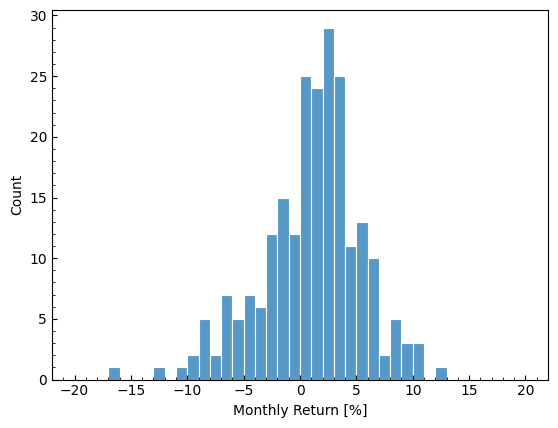

In [ ]:
#### not sure if this is useful... could be cool to do a 2D kde plot of returns to see correlation
fig, ax = plt.subplots()
sns.histplot(returns['SPY'] * 100, edgecolor='w', bins=np.arange(-20,21,1))
# sns.kdeplot(returns['SPY'] * 100, fill=True, zorder=10)
ax.set_xlabel('Monthly Return [%]')
plt.plot()

In [127]:
def get_annualized_sharpe(excess_returns_series, vals_per_year=12):
    '''
    Returns the annualized sharpe ratio
    for the given series of excess returns
    '''
    mean_return = np.mean(excess_returns_series)
    stdv_return = np.std(excess_returns_series)

    return np.sqrt(vals_per_year) * mean_return / stdv_return


def get_drawdown(returns_series):
    '''
    Returns the pct drawdown series
    for the given returns series
    '''
    running_value = (returns_series + 1).cumprod()
    running_max   = running_value.cummax()

    drawdown_pct  = ((running_value / running_max) - 1) * 100.

    return drawdown_pct

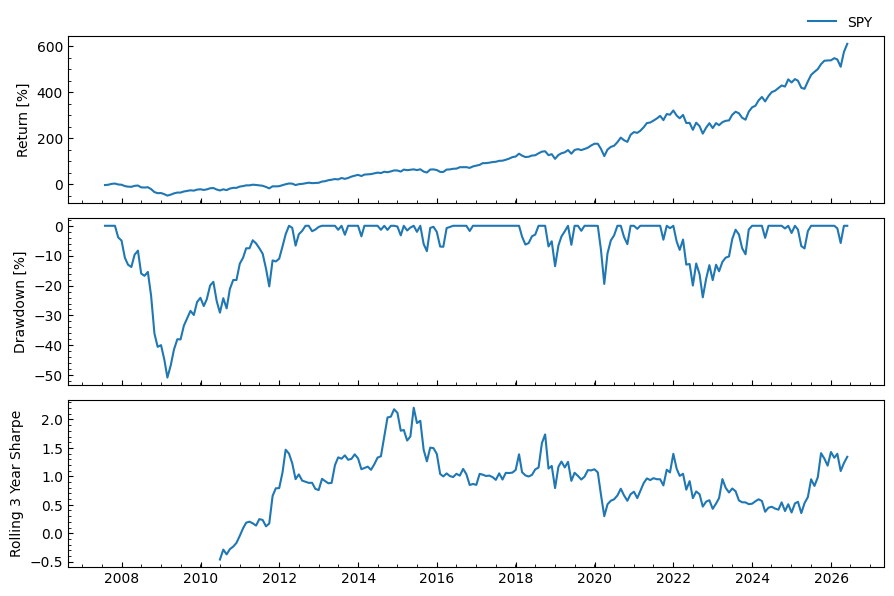

In [135]:
tickers = ['SPY']

fig, axs = plt.subplots(nrows=3, figsize=(9, 6), sharex=True)

ax = axs[0]
ax.plot(((returns[tickers] + 1).cumprod() - 1) * 100., label=tickers)
ax.set_ylabel('Return [%]')

ax.legend(loc            = 'upper right',
          bbox_to_anchor = (1, 1.2),
          ncols          = 1,
          frameon        = False,
          )

ax = axs[1]
ax.plot(get_drawdown(returns[tickers]))
ax.set_ylabel('Drawdown [%]')

ax = axs[2]
ax.plot(excess_returns['SPY'].rolling(window=36).apply(get_annualized_sharpe))
ax.set_ylabel('Rolling 3 Year Sharpe')

fig.tight_layout()
plt.show()

### Simple Portfolio of Stocks (SPY) and Bonds (LQD)

In [175]:
portfolio_name    = 'STOCK_BOND'
portfolio_weights = {'SPY' : 0.6,
                     'LQD' : 0.4,
                     }

if sum(list(portfolio_weights.values())) != 1:
    raise ValueError('Portfolio weights don\'t sum to 1!')

portfolio_returns = returns.mul(pd.Series(portfolio_weights)).sum(axis=1)
portfolio_returns = pd.DataFrame(portfolio_returns, columns=[portfolio_name])

stock_bond_df = returns[['SPY', 'LQD']].copy()
stock_bond_df = stock_bond_df.join(portfolio_returns)

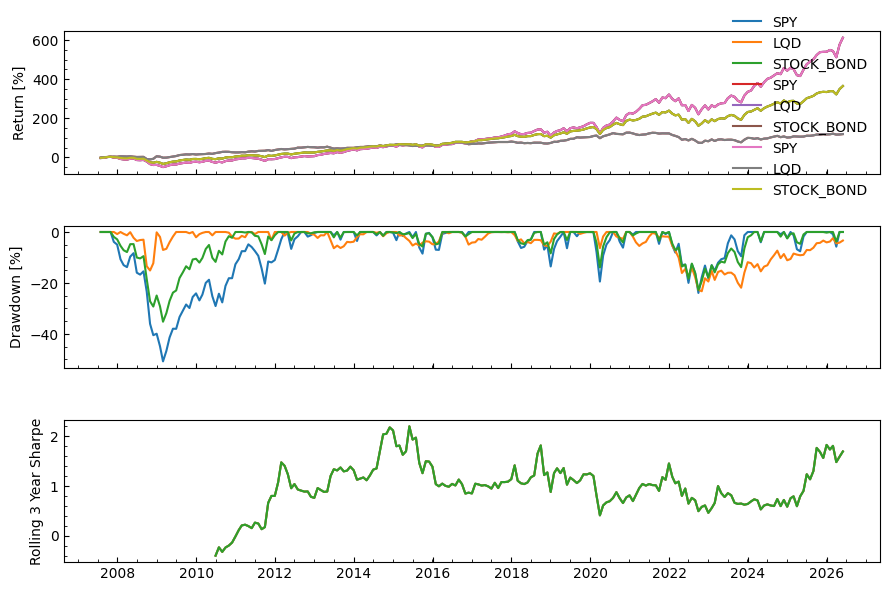

In [177]:
tickers = ['SPY', 'LQD', 'STOCK_BOND']

fig, axs = plt.subplots(nrows=3, figsize=(9, 6), sharex=True)

for ticker in tickers:
    ax = axs[0]
    ax.plot(((stock_bond_df[tickers] + 1).cumprod() - 1) * 100., label=tickers)
    ax.set_ylabel('Return [%]')

    ax.legend(loc            = 'upper right',
            bbox_to_anchor = (1, 1.2),
            ncols          = 1,
            frameon        = False,
            )

    ax = axs[1]
    ax.plot(get_drawdown(stock_bond_df[ticker]))
    ax.set_ylabel('Drawdown [%]')

    ax = axs[2]
    ax.plot(stock_bond_df['SPY'].rolling(window=36).apply(get_annualized_sharpe)) #######################
    ax.set_ylabel('Rolling 3 Year Sharpe')

fig.tight_layout()
plt.show()